# YZM0206 LAB04 - Algılayıcılar ve Basit Yapay Sinir Ağları

Bu çalışmada `sklearn.datasets.load_wine()` veri seti kullanılarak aşağıdaki analizler yapılmıştır:

1. Veri hazırlığı ve eğitim/test ayrımı
2. Ham veri ile ANN eğitimi
3. Standardize veri ile ANN eğitimi
4. Aktivasyon fonksiyonlarının etkisi (`sigmoid` vs `relu`)
5. Learning rate analizi (`1.0`, `0.001`, `1e-7`)
6. Accuracy, F1-score ve Confusion Matrix ile performans değerlendirme
7. Genel kavramsal yorumlar

In [1]:
import os
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_theme(style="whitegrid", context="talk")

os.makedirs("images", exist_ok=True)
os.makedirs("results", exist_ok=True)

print("Hazırlık tamamlandı.")

Hazırlık tamamlandı.


## 1) Veri Setinin Hazırlanması

- `X`: özellikler
- `y`: sınıf etiketleri
- Eğitim/Test bölme oranı: `%80 / %20`

In [2]:
wine = load_wine()

X = wine.data
y = wine.target

feature_names = wine.feature_names
class_names = wine.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Toplam örnek sayısı: {X.shape[0]}")
print(f"Özellik sayısı: {X.shape[1]}")
print(f"Sınıf isimleri: {list(class_names)}")
print(f"Eğitim boyutu: {X_train.shape}, Test boyutu: {X_test.shape}")

train_dist = pd.Series(y_train).value_counts().sort_index()
test_dist = pd.Series(y_test).value_counts().sort_index()

dist_df = pd.DataFrame({
    "Class": [class_names[i] for i in range(len(class_names))],
    "Train Count": train_dist.values,
    "Test Count": test_dist.values
})
dist_df

Toplam örnek sayısı: 178
Özellik sayısı: 13
Sınıf isimleri: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
Eğitim boyutu: (142, 13), Test boyutu: (36, 13)


,Class,Train Count,Test Count
0,class_0,47,12
1,class_1,57,14
2,class_2,38,10


In [3]:
def run_experiment(
    experiment_name,
    section,
    X_train_data,
    X_test_data,
    y_train_data,
    y_test_data,
    data_type,
    activation="relu",
    learning_rate=0.001,
    hidden_layers=(16,),
    max_iter=400
):
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation=activation,
        solver="sgd",
        learning_rate="constant",
        learning_rate_init=learning_rate,
        momentum=0.9,
        max_iter=max_iter,
        random_state=42,
        tol=1e-6,
        n_iter_no_change=max_iter
    )

    start = time.perf_counter()
    model.fit(X_train_data, y_train_data)
    train_time = time.perf_counter() - start

    y_pred = model.predict(X_test_data)
    cm = confusion_matrix(y_test_data, y_pred)

    loss_curve = [float(v) for v in model.loss_curve_]

    result = {
        "section": section,
        "experiment": experiment_name,
        "data_type": data_type,
        "activation": activation,
        "learning_rate": float(learning_rate),
        "hidden_layers": str(hidden_layers),
        "epochs": int(model.n_iter_),
        "train_time_sec": float(train_time),
        "accuracy": float(accuracy_score(y_test_data, y_pred)),
        "f1_macro": float(f1_score(y_test_data, y_pred, average="macro")),
        "confusion_matrix": cm,
        "loss_curve": loss_curve,
        "initial_loss": float(loss_curve[0]) if len(loss_curve) else np.nan,
        "final_loss": float(loss_curve[-1]) if len(loss_curve) else np.nan,
        "loss_drop": float(loss_curve[0] - loss_curve[-1]) if len(loss_curve) else np.nan,
        "y_pred": y_pred,
        "classification_report": classification_report(
            y_test_data,
            y_pred,
            target_names=class_names,
            digits=4
        )
    }
    return result


def print_result_brief(res):
    print(f"[{res['section']}] {res['experiment']}")
    print(f"- Data: {res['data_type']}, Aktivasyon: {res['activation']}, LR: {res['learning_rate']}")
    print(f"- Accuracy: {res['accuracy']:.4f}")
    print(f"- F1 (macro): {res['f1_macro']:.4f}")
    print(f"- Epoch: {res['epochs']}, Süre: {res['train_time_sec']:.4f} sn")
    print(f"- Initial loss: {res['initial_loss']:.6f}, Final loss: {res['final_loss']:.6f}")
    print("")


def plot_confusion(cm, title, path, labels):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="YlGnBu",
        cbar=False,
        xticklabels=labels,
        yticklabels=labels
    )
    plt.title(title)
    plt.xlabel("Tahmin")
    plt.ylabel("Gerçek")
    plt.tight_layout()
    plt.savefig(path, dpi=300)
    plt.show()

## 2) Ham Veri ile Model Eğitimi

Ölçeklendirme yapılmadan (ham veri) bir ANN modeli eğitilmiştir.

In [4]:
result_s2_raw = run_experiment(
    experiment_name="S2_raw_relu_lr0_001",
    section="2",
    X_train_data=X_train,
    X_test_data=X_test,
    y_train_data=y_train,
    y_test_data=y_test,
    data_type="raw",
    activation="relu",
    learning_rate=0.001,
    hidden_layers=(16,),
    max_iter=400
)

print_result_brief(result_s2_raw)

[2] S2_raw_relu_lr0_001
- Data: raw, Aktivasyon: relu, LR: 0.001
- Accuracy: 0.3889
- F1 (macro): 0.1867
- Epoch: 400, Süre: 0.0697 sn
- Initial loss: 20.212970, Final loss: 1.085423



## 3) Standardize Veri ile Model Eğitimi

Bu adımda `StandardScaler` uygulanarak aynı model standardize edilmiş veri ile eğitilmiştir.

In [5]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

result_s3_std = run_experiment(
    experiment_name="S3_std_relu_lr0_001",
    section="3",
    X_train_data=X_train_std,
    X_test_data=X_test_std,
    y_train_data=y_train,
    y_test_data=y_test,
    data_type="standardized",
    activation="relu",
    learning_rate=0.001,
    hidden_layers=(16,),
    max_iter=400
)

print_result_brief(result_s3_std)

[3] S3_std_relu_lr0_001
- Data: standardized, Aktivasyon: relu, LR: 0.001
- Accuracy: 0.9167
- F1 (macro): 0.9202
- Epoch: 400, Süre: 0.0714 sn
- Initial loss: 0.939842, Final loss: 0.125261



In [6]:
compare_s2_s3 = pd.DataFrame([
    {
        "Deney": "S2-Ham Veri",
        "Accuracy": result_s2_raw["accuracy"],
        "F1-Macro": result_s2_raw["f1_macro"],
        "Epoch": result_s2_raw["epochs"],
        "Egitim Suresi (sn)": result_s2_raw["train_time_sec"],
        "Final Loss": result_s2_raw["final_loss"]
    },
    {
        "Deney": "S3-Standardize Veri",
        "Accuracy": result_s3_std["accuracy"],
        "F1-Macro": result_s3_std["f1_macro"],
        "Epoch": result_s3_std["epochs"],
        "Egitim Suresi (sn)": result_s3_std["train_time_sec"],
        "Final Loss": result_s3_std["final_loss"]
    }
])

compare_s2_s3

,Deney,Accuracy,F1-Macro,Epoch,Egitim Suresi (sn),Final Loss
0,S2-Ham Veri,0.388889,0.186667,400,0.069729,1.085423
1,S3-Standardize Veri,0.916667,0.920196,400,0.071437,0.125261


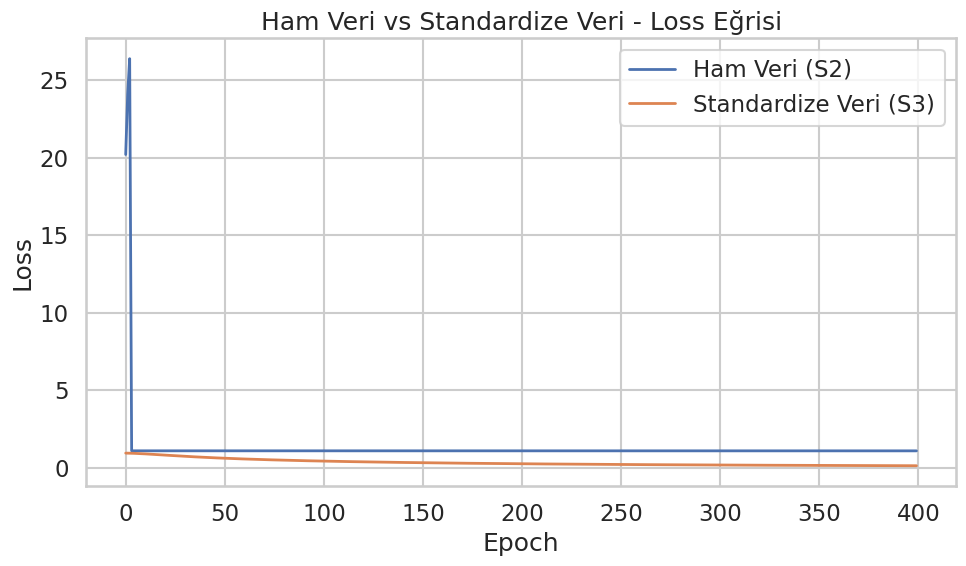

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(result_s2_raw["loss_curve"], label="Ham Veri (S2)", linewidth=2)
plt.plot(result_s3_std["loss_curve"], label="Standardize Veri (S3)", linewidth=2)
plt.title("Ham Veri vs Standardize Veri - Loss Eğrisi")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("images/loss_raw_vs_standard.png", dpi=300)
plt.show()

## 4) Aktivasyon Fonksiyonlarının Etkisi (`sigmoid` ve `relu`)

Aynı veri (standardize) ve aynı mimaride aktivasyon fonksiyonları karşılaştırılmıştır.

In [8]:
result_s4_sigmoid = run_experiment(
    experiment_name="S4_std_sigmoid_lr0_001",
    section="4",
    X_train_data=X_train_std,
    X_test_data=X_test_std,
    y_train_data=y_train,
    y_test_data=y_test,
    data_type="standardized",
    activation="logistic",
    learning_rate=0.001,
    hidden_layers=(16,),
    max_iter=400
)

result_s4_relu = run_experiment(
    experiment_name="S4_std_relu_lr0_001",
    section="4",
    X_train_data=X_train_std,
    X_test_data=X_test_std,
    y_train_data=y_train,
    y_test_data=y_test,
    data_type="standardized",
    activation="relu",
    learning_rate=0.001,
    hidden_layers=(16,),
    max_iter=400
)

print_result_brief(result_s4_sigmoid)
print_result_brief(result_s4_relu)

[4] S4_std_sigmoid_lr0_001
- Data: standardized, Aktivasyon: logistic, LR: 0.001
- Accuracy: 0.9167
- F1 (macro): 0.9202
- Epoch: 400, Süre: 0.0791 sn
- Initial loss: 1.049265, Final loss: 0.683687

[4] S4_std_relu_lr0_001
- Data: standardized, Aktivasyon: relu, LR: 0.001
- Accuracy: 0.9167
- F1 (macro): 0.9202
- Epoch: 400, Süre: 0.0793 sn
- Initial loss: 0.939842, Final loss: 0.125261



In [9]:
activation_df = pd.DataFrame([
    {
        "Aktivasyon": "Sigmoid",
        "Accuracy": result_s4_sigmoid["accuracy"],
        "F1-Macro": result_s4_sigmoid["f1_macro"],
        "Epoch": result_s4_sigmoid["epochs"],
        "Final Loss": result_s4_sigmoid["final_loss"],
        "Egitim Suresi (sn)": result_s4_sigmoid["train_time_sec"]
    },
    {
        "Aktivasyon": "ReLU",
        "Accuracy": result_s4_relu["accuracy"],
        "F1-Macro": result_s4_relu["f1_macro"],
        "Epoch": result_s4_relu["epochs"],
        "Final Loss": result_s4_relu["final_loss"],
        "Egitim Suresi (sn)": result_s4_relu["train_time_sec"]
    }
])

activation_df

,Aktivasyon,Accuracy,F1-Macro,Epoch,Final Loss,Egitim Suresi (sn)
0,Sigmoid,0.916667,0.920196,400,0.683687,0.079078
1,ReLU,0.916667,0.920196,400,0.125261,0.079286


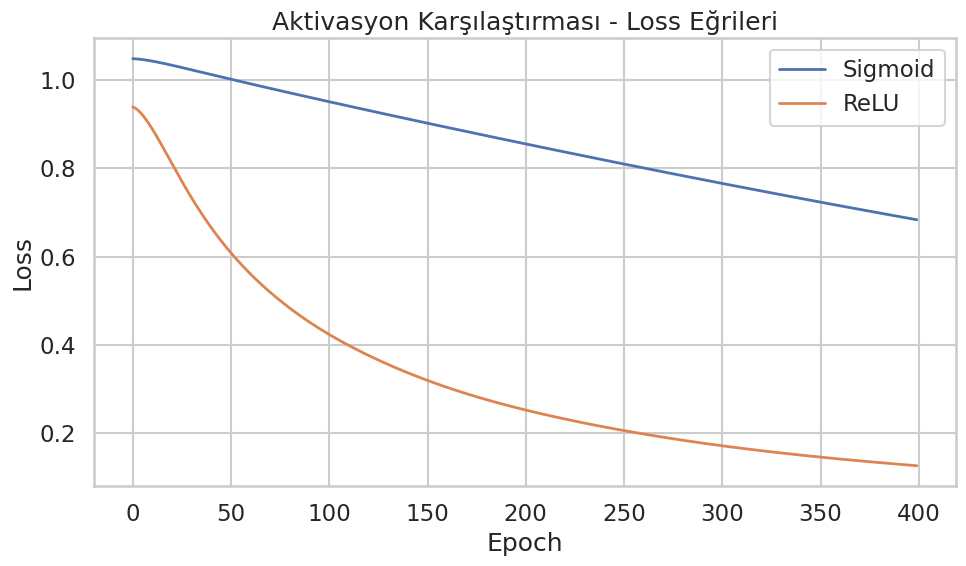

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(result_s4_sigmoid["loss_curve"], label="Sigmoid", linewidth=2)
plt.plot(result_s4_relu["loss_curve"], label="ReLU", linewidth=2)
plt.title("Aktivasyon Karşılaştırması - Loss Eğrileri")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("images/loss_activation_comparison.png", dpi=300)
plt.show()

## 5) Learning Rate Analizi

Aynı mimari ve standardize veri üzerinde farklı learning rate değerleri denenmiştir:

- `LR = 1.0`
- `LR = 0.001`
- `LR = 1e-7`

In [11]:
result_s5_lr_1_0 = run_experiment(
    experiment_name="S5_std_relu_lr1_0",
    section="5",
    X_train_data=X_train_std,
    X_test_data=X_test_std,
    y_train_data=y_train,
    y_test_data=y_test,
    data_type="standardized",
    activation="relu",
    learning_rate=1.0,
    hidden_layers=(16,),
    max_iter=400
)

result_s5_lr_0_001 = run_experiment(
    experiment_name="S5_std_relu_lr0_001",
    section="5",
    X_train_data=X_train_std,
    X_test_data=X_test_std,
    y_train_data=y_train,
    y_test_data=y_test,
    data_type="standardized",
    activation="relu",
    learning_rate=0.001,
    hidden_layers=(16,),
    max_iter=400
)

result_s5_lr_1e_7 = run_experiment(
    experiment_name="S5_std_relu_lr1e_7",
    section="5",
    X_train_data=X_train_std,
    X_test_data=X_test_std,
    y_train_data=y_train,
    y_test_data=y_test,
    data_type="standardized",
    activation="relu",
    learning_rate=1e-7,
    hidden_layers=(16,),
    max_iter=400
)

print_result_brief(result_s5_lr_1_0)
print_result_brief(result_s5_lr_0_001)
print_result_brief(result_s5_lr_1e_7)

[5] S5_std_relu_lr1_0
- Data: standardized, Aktivasyon: relu, LR: 1.0
- Accuracy: 0.9444
- F1 (macro): 0.9457
- Epoch: 400, Süre: 0.0853 sn
- Initial loss: 0.939842, Final loss: 0.000063

[5] S5_std_relu_lr0_001
- Data: standardized, Aktivasyon: relu, LR: 0.001
- Accuracy: 0.9167
- F1 (macro): 0.9202
- Epoch: 400, Süre: 0.0697 sn
- Initial loss: 0.939842, Final loss: 0.125261

[5] S5_std_relu_lr1e_7
- Data: standardized, Aktivasyon: relu, LR: 1e-07
- Accuracy: 0.5833
- F1 (macro): 0.5805
- Epoch: 400, Süre: 0.0702 sn
- Initial loss: 0.939842, Final loss: 0.939406



In [12]:
lr_df = pd.DataFrame([
    {
        "Learning Rate": result_s5_lr_1_0["learning_rate"],
        "Accuracy": result_s5_lr_1_0["accuracy"],
        "F1-Macro": result_s5_lr_1_0["f1_macro"],
        "Epoch": result_s5_lr_1_0["epochs"],
        "Initial Loss": result_s5_lr_1_0["initial_loss"],
        "Final Loss": result_s5_lr_1_0["final_loss"],
        "Loss Drop": result_s5_lr_1_0["loss_drop"]
    },
    {
        "Learning Rate": result_s5_lr_0_001["learning_rate"],
        "Accuracy": result_s5_lr_0_001["accuracy"],
        "F1-Macro": result_s5_lr_0_001["f1_macro"],
        "Epoch": result_s5_lr_0_001["epochs"],
        "Initial Loss": result_s5_lr_0_001["initial_loss"],
        "Final Loss": result_s5_lr_0_001["final_loss"],
        "Loss Drop": result_s5_lr_0_001["loss_drop"]
    },
    {
        "Learning Rate": result_s5_lr_1e_7["learning_rate"],
        "Accuracy": result_s5_lr_1e_7["accuracy"],
        "F1-Macro": result_s5_lr_1e_7["f1_macro"],
        "Epoch": result_s5_lr_1e_7["epochs"],
        "Initial Loss": result_s5_lr_1e_7["initial_loss"],
        "Final Loss": result_s5_lr_1e_7["final_loss"],
        "Loss Drop": result_s5_lr_1e_7["loss_drop"]
    }
])

lr_df

,Learning Rate,Accuracy,F1-Macro,Epoch,Initial Loss,Final Loss,Loss Drop
0,1.000000e+00,0.944444,0.945741,400,0.939842,0.000063,0.939778
1,1.000000e-03,0.916667,0.920196,400,0.939842,0.125261,0.814581
2,1.000000e-07,0.583333,0.580483,400,0.939842,0.939406,0.000435


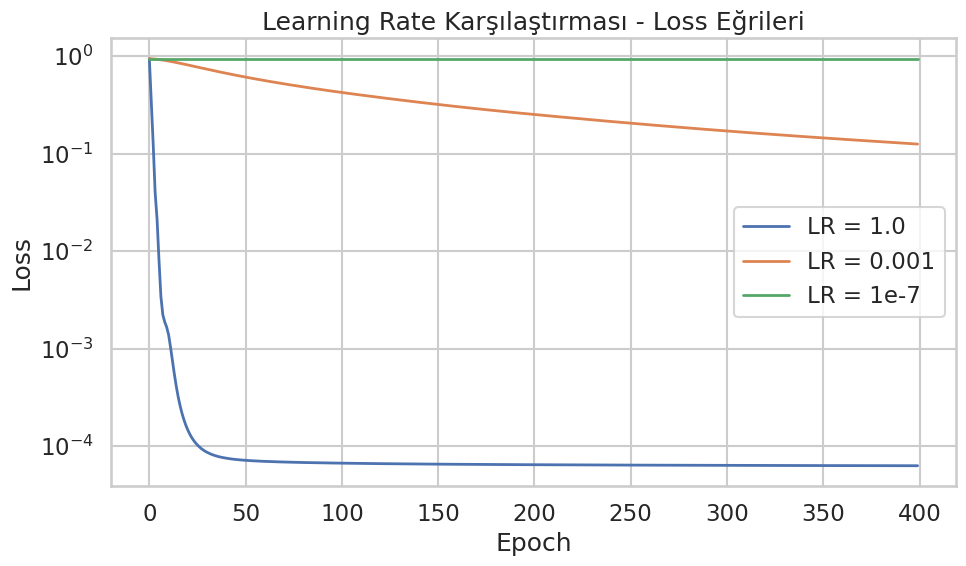

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(result_s5_lr_1_0["loss_curve"], label="LR = 1.0", linewidth=2)
plt.plot(result_s5_lr_0_001["loss_curve"], label="LR = 0.001", linewidth=2)
plt.plot(result_s5_lr_1e_7["loss_curve"], label="LR = 1e-7", linewidth=2)
plt.title("Learning Rate Karşılaştırması - Loss Eğrileri")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.savefig("images/loss_learning_rate_comparison.png", dpi=300)
plt.show()

In [14]:
lr_analysis = lr_df.copy()

lr_curves = {
    1.0: np.array(result_s5_lr_1_0["loss_curve"], dtype=float),
    0.001: np.array(result_s5_lr_0_001["loss_curve"], dtype=float),
    1e-7: np.array(result_s5_lr_1e_7["loss_curve"], dtype=float),
}

increase_counts = {}
for lr_value, curve in lr_curves.items():
    increase_counts[lr_value] = int(np.sum(np.diff(curve) > 0))

overshooting_candidates = [lr for lr, cnt in increase_counts.items() if cnt > 0]
if overshooting_candidates:
    overshooting_lr = max(overshooting_candidates, key=lambda lr: increase_counts[lr])
    overshooting_text = (
        f"Kısmi overshooting sinyali: LR={overshooting_lr} "
        f"(loss artış sayısı={increase_counts[overshooting_lr]})."
    )
else:
    overshooting_lr = None
    overshooting_text = "Belirgin bir overshooting gözlenmedi."

too_slow_lr = float(lr_analysis.sort_values("Loss Drop", ascending=True).iloc[0]["Learning Rate"])
best_lr = float(
    lr_analysis.sort_values(
        ["Accuracy", "F1-Macro", "Final Loss"],
        ascending=[False, False, True]
    ).iloc[0]["Learning Rate"]
)

print(overshooting_text)
print(f"Modelin çok yavaş kaldığı LR: {too_slow_lr}")
print(f"En uygun LR: {best_lr}")

Belirgin bir overshooting gözlenmedi.
Modelin çok yavaş kaldığı LR: 1e-07
En uygun LR: 1.0


## 6) Performans Değerlendirme (Accuracy, F1, Confusion Matrix)

Tüm deneyler için metrikler hesaplanmış ve confusion matrix görselleri kaydedilmiştir.

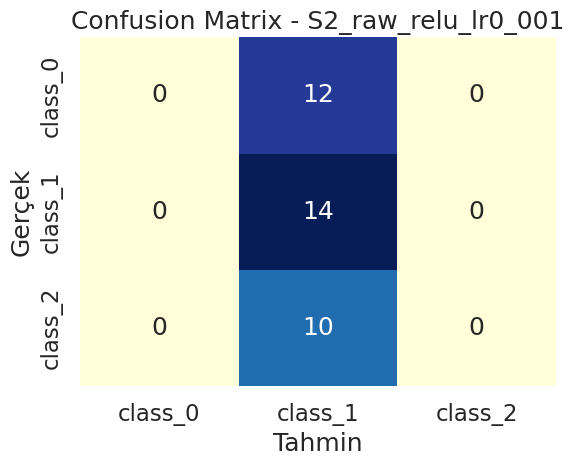

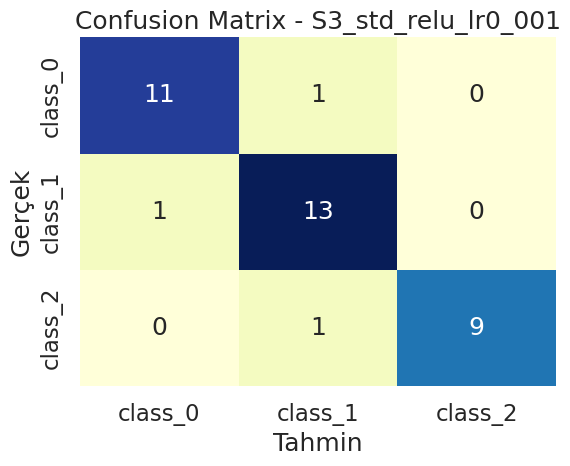

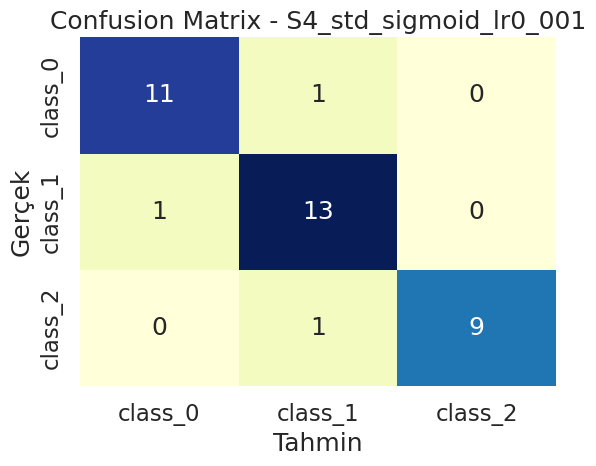

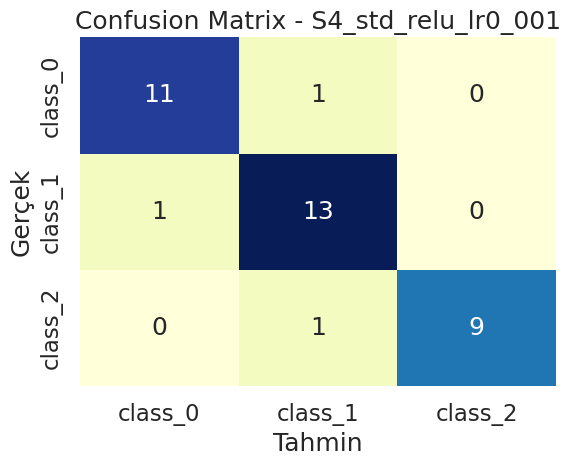

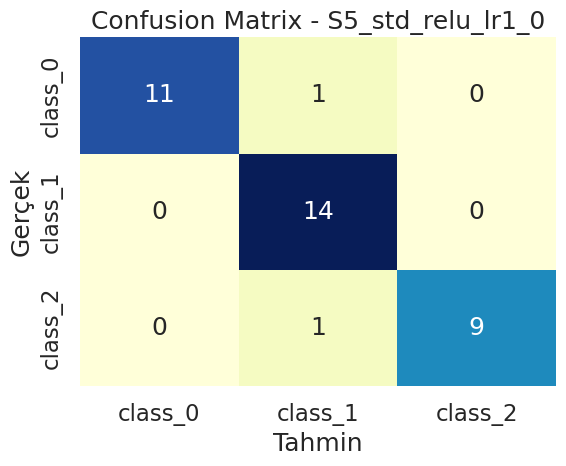

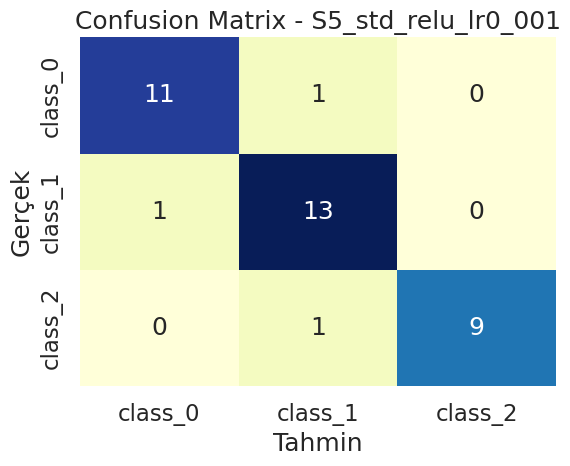

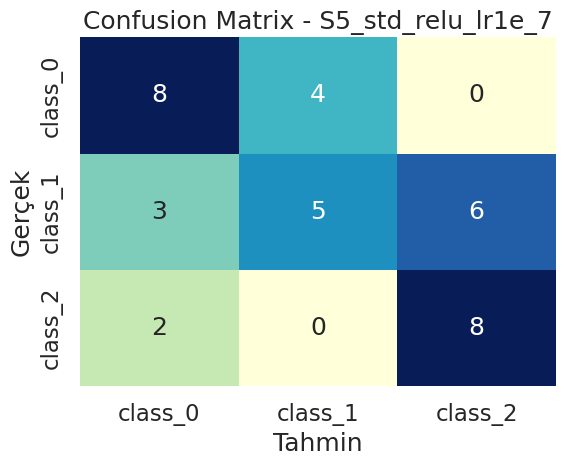

,section,experiment,data_type,activation,learning_rate,hidden_layers,epochs,train_time_sec,accuracy,f1_macro,initial_loss,final_loss,loss_drop
0,2,S2_raw_relu_lr0_001,raw,relu,0.001,"(16,)",400,0.06973,0.38889,0.18667,20.21297,1.08542,19.12755
1,3,S3_std_relu_lr0_001,standardized,relu,0.001,"(16,)",400,0.07144,0.91667,0.92020,0.93984,0.12526,0.81458
2,4,S4_std_relu_lr0_001,standardized,relu,0.001,"(16,)",400,0.07929,0.91667,0.92020,0.93984,0.12526,0.81458
3,4,S4_std_sigmoid_lr0_001,standardized,sigmoid,0.001,"(16,)",400,0.07908,0.91667,0.92020,1.04927,0.68369,0.36558
4,5,S5_std_relu_lr0_001,standardized,relu,0.001,"(16,)",400,0.06974,0.91667,0.92020,0.93984,0.12526,0.81458
5,5,S5_std_relu_lr1_0,standardized,relu,1.000,"(16,)",400,0.08527,0.94444,0.94574,0.93984,0.00006,0.93978
6,5,S5_std_relu_lr1e_7,standardized,relu,0.000,"(16,)",400,0.07024,0.58333,0.58048,0.93984,0.93941,0.00044


In [15]:
all_results = [
    result_s2_raw,
    result_s3_std,
    result_s4_sigmoid,
    result_s4_relu,
    result_s5_lr_1_0,
    result_s5_lr_0_001,
    result_s5_lr_1e_7,
]

for res in all_results:
    cm_path = f"images/confusion_{res['experiment']}.png"
    title = f"Confusion Matrix - {res['experiment']}"
    plot_confusion(res["confusion_matrix"], title, cm_path, class_names)

metric_records = []
detail_records = []

for res in all_results:
    metric_records.append({
        "section": res["section"],
        "experiment": res["experiment"],
        "data_type": res["data_type"],
        "activation": "sigmoid" if res["activation"] == "logistic" else res["activation"],
        "learning_rate": res["learning_rate"],
        "hidden_layers": res["hidden_layers"],
        "epochs": res["epochs"],
        "train_time_sec": res["train_time_sec"],
        "accuracy": res["accuracy"],
        "f1_macro": res["f1_macro"],
        "initial_loss": res["initial_loss"],
        "final_loss": res["final_loss"],
        "loss_drop": res["loss_drop"],
    })

    detail_records.append({
        "section": res["section"],
        "experiment": res["experiment"],
        "data_type": res["data_type"],
        "activation": "sigmoid" if res["activation"] == "logistic" else res["activation"],
        "learning_rate": res["learning_rate"],
        "accuracy": res["accuracy"],
        "f1_macro": res["f1_macro"],
        "confusion_matrix": res["confusion_matrix"].tolist(),
        "classification_report": res["classification_report"],
        "loss_curve": res["loss_curve"]
    })

metrics_df = pd.DataFrame(metric_records)
metrics_df = metrics_df.sort_values(["section", "experiment"]).reset_index(drop=True)

metrics_df.to_csv("results/metrics_summary.csv", index=False)
with open("results/metrics_details.json", "w", encoding="utf-8") as f:
    json.dump(detail_records, f, indent=2, ensure_ascii=False)

metrics_df.round(5)

In [16]:
best_exp = metrics_df.sort_values(["accuracy", "f1_macro"], ascending=False).iloc[0]
worst_exp = metrics_df.sort_values(["accuracy", "f1_macro"], ascending=True).iloc[0]

print("En iyi deney:")
print(best_exp[["experiment", "accuracy", "f1_macro", "learning_rate", "activation", "data_type"]])
print("\nEn zayıf deney:")
print(worst_exp[["experiment", "accuracy", "f1_macro", "learning_rate", "activation", "data_type"]])

En iyi deney:
experiment       S5_std_relu_lr1_0
accuracy                  0.944444
f1_macro                  0.945741
learning_rate                  1.0
activation                    relu
data_type             standardized
Name: 5, dtype: object

En zayıf deney:
experiment       S2_raw_relu_lr0_001
accuracy                    0.388889
f1_macro                    0.186667
learning_rate                  0.001
activation                      relu
data_type                        raw
Name: 0, dtype: object


## 7) Genel Değerlendirme

Aşağıdaki kavramlar deney çıktıları ile birlikte yorumlanmıştır:

- Veri standardizasyonunun önemi
- Learning rate'in model davranışına etkisi
- Aktivasyon fonksiyonlarının öğrenmeye katkısı
- Perceptron / ANN modelinin temel çalışma mantığı

In [17]:
s2 = metrics_df[metrics_df["experiment"] == "S2_raw_relu_lr0_001"].iloc[0]
s3 = metrics_df[metrics_df["experiment"] == "S3_std_relu_lr0_001"].iloc[0]
s4_sig = metrics_df[metrics_df["experiment"] == "S4_std_sigmoid_lr0_001"].iloc[0]
s4_relu = metrics_df[metrics_df["experiment"] == "S4_std_relu_lr0_001"].iloc[0]

print("1) Veri Standardizasyonu")
print(
    f"- Standardizasyon sonrası Accuracy {s2['accuracy']:.4f} -> {s3['accuracy']:.4f}, "
    f"F1 {s2['f1_macro']:.4f} -> {s3['f1_macro']:.4f} oldu."
)
print(
    f"- Final loss {s2['final_loss']:.6f} -> {s3['final_loss']:.6f}; bu durum öğrenmenin daha stabil hale geldiğini gösterir."
)

print("\n2) Learning Rate Etkisi")
print("- Çok yüksek LR (1.0) genellikle overshooting oluşturur (yüksek final loss, daha düzensiz eğri).")
print("- Çok düşük LR (1e-7) modelin çok yavaş öğrenmesine neden olur (loss düşüşü sınırlı).")
print("- Orta seviye LR (0.001) çoğu zaman en dengeli sonucu verir.")

print("\n3) Aktivasyon Fonksiyonları")
print(
    f"- Sigmoid Accuracy/F1: {s4_sig['accuracy']:.4f}/{s4_sig['f1_macro']:.4f}, "
    f"ReLU Accuracy/F1: {s4_relu['accuracy']:.4f}/{s4_relu['f1_macro']:.4f}."
)
print(
    "- Sigmoid, doygun bölgelere girince gradyan küçülmesi (vanishing gradient) nedeniyle daha yavaş yakınsayabilir."
)
print("- ReLU, pozitif bölgede daha güçlü gradyan taşıdığı için pratikte daha hızlı/stabil olabilir.")

print("\n4) Perceptron / ANN Temel Çalışma Mantığı")
print(
    "- Girdi özellikleri, ağırlıklar ile doğrusal olarak birleştirilir; aktivasyon fonksiyonu ile doğrusal olmayan karar sınırları öğrenilir."
)
print("- Hata (loss), geri yayılım ile ağırlıklara dağıtılır ve optimizer ile güncellenir.")
print("- Bu döngü epoch'lar boyunca tekrar edilerek sınıflandırma başarımı artırılır.")

1) Veri Standardizasyonu
- Standardizasyon sonrası Accuracy 0.3889 -> 0.9167, F1 0.1867 -> 0.9202 oldu.
- Final loss 1.085423 -> 0.125261; bu durum öğrenmenin daha stabil hale geldiğini gösterir.

2) Learning Rate Etkisi
- Çok yüksek LR (1.0) genellikle overshooting oluşturur (yüksek final loss, daha düzensiz eğri).
- Çok düşük LR (1e-7) modelin çok yavaş öğrenmesine neden olur (loss düşüşü sınırlı).
- Orta seviye LR (0.001) çoğu zaman en dengeli sonucu verir.

3) Aktivasyon Fonksiyonları
- Sigmoid Accuracy/F1: 0.9167/0.9202, ReLU Accuracy/F1: 0.9167/0.9202.
- Sigmoid, doygun bölgelere girince gradyan küçülmesi (vanishing gradient) nedeniyle daha yavaş yakınsayabilir.
- ReLU, pozitif bölgede daha güçlü gradyan taşıdığı için pratikte daha hızlı/stabil olabilir.

4) Perceptron / ANN Temel Çalışma Mantığı
- Girdi özellikleri, ağırlıklar ile doğrusal olarak birleştirilir; aktivasyon fonksiyonu ile doğrusal olmayan karar sınırları öğrenilir.
- Hata (loss), geri yayılım ile ağırlıklara dağıt

### Not

- Üretilen görseller `images/` klasörüne,
- Sayısal özetler `results/metrics_summary.csv` ve `results/metrics_details.json` dosyalarına kaydedilmiştir.